In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [7]:
scalar = np.array(5)
vector = np.array([4,6,1])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 5, 2))
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 5, 2)


In [8]:
A = np.arange(6).reshape(2, 3)
B = np.ones((2, 3), dtype=int)
print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [9]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [10]:
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])
print('a . b  (dot)   :', np.dot(a, b))
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [11]:
print('L2 norm  ||a||_2 :', la.norm(a))
print('L1 norm  ||a||_1 :', la.norm(a, 1))
print('Linf norm        :', la.norm(a, np.inf))
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [14]:
A = np.array([[1,2],
              [6,7]])
B = np.array([[2,5],
              [5,6]])
print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[12 17]
 [47 72]]
A.T   (transpose):
 [[1 6]
 [2 7]]
inverse(A):
 [[-1.4  0.4]
 [ 1.2 -0.2]]
trace(A) = sum of diagonal: 8


In [15]:
I = np.eye(2)
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))
print('A symmetric?', np.allclose(A, A.T))
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? False
Q orthogonal? True


In [17]:
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
scaled  = S @ square
rotated = R @ square
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


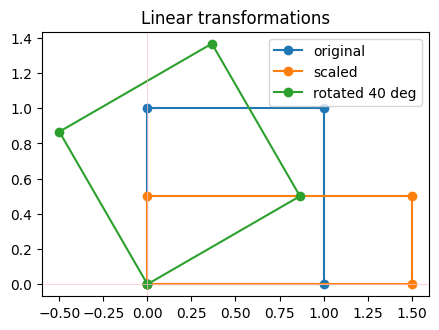

In [22]:
def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 40 deg')
ax.axhline(0, color='pink', lw=0.5); ax.axvline(0, color='pink', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

In [23]:
A = np.array([[2., 0.],
              [0., 3.]])
vals, vecs = la.eig(A)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)
for i in range(len(vals)):
    v = vecs[:, i]
    lhs = A @ v
    rhs = vals[i] * v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [24]:
A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)
print('Rank of A :', la.matrix_rank(A))
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [25]:
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [26]:
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])
print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [29]:
A2 = np.array([[3, 2],
               [1, 4]])
b2 = np.array([7, 9])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])
x=la.solve(A2,b2)
print('solution of x:',x)
print('rank of A2:',la.matrix_rank(A2))
print('cosine(cat, dog):', round(cosine(cat, dog), 3))
print('cosine(cat, car):', round(cosine(cat, car), 3))

solution of x: [1. 2.]
rank of A2: 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293


In [31]:
C = np.array([[4., 1.],
              [2., 3.]])
val,vec=la.eig(C)
print('eigen values:',val)
print('eigen vectors:',vec)
for i in range(len(val)):
    v = vec[:, i]
    lhs = C@ v
    rhs = val[i] * v
    print(f'lambda={val[i]:.1f}  C v == lambda v ?', np.allclose(lhs, rhs))

eigen values: [5. 2.]
eigen vectors: [[ 0.707 -0.447]
 [ 0.707  0.894]]
lambda=5.0  C v == lambda v ? True
lambda=2.0  C v == lambda v ? True


Rotated corners:
 [[ 0.     0.707 -0.354]
 [ 0.     0.707  1.061]]


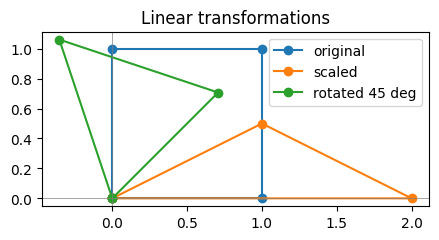

In [33]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ tri
rotated = R @ tri
print('Rotated corners:\n', rotated)
def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 45 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()


In [36]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])
inv=la.inv(M)
print('inverse:',inv)
print('trace:',np.trace(M))
print('M @ inv(M)==I?', np.allclose(M @ inv, I))

inverse: [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace: 7.0
M @ inv(M)==I? True


In [37]:

T = np.arange(12).reshape(3, 4)
print('T:\n', T)
print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')
print('T + T (element-wise add):\n', T+T)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
tensor  ndim=3  shape=(3, 5, 2)
T + T (element-wise add):
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
